
# TMDB Movie Quality Classification & Plot Similarity Analysis

Movie Quality Classification using LSTM and NLP  
Plot Similarity (Cosine)


## Imports

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Concatenate
from tensorflow.keras.utils import to_categorical


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
import warnings
warnings.filterwarnings("ignore")


## Load Dataset

In [4]:
df = pd.read_csv('movies.csv')
df.shape

(722317, 20)

In [5]:

df = pd.read_csv('movies.csv')
df = df[['title','overview','runtime','budget','genres','original_language','vote_average']]
df['title'] = df['title'].fillna('').astype(str)
df['overview'] = df['overview'].fillna('').astype(str)
df['genres'] = df['genres'].fillna('Unknown').astype(str)
df['original_language'] = df['original_language'].fillna(df['original_language'].mode()[0])

df = df[(df['runtime'] >= 20) & (df['runtime'] <= 500)]

df.shape


(409488, 7)

## Target Engineering

In [6]:

def quality_label(r):
    if r < 5:
        return 0
    elif r < 6:
        return 1
    elif r < 7.5:
        return 2
    else:
        return 3

df['quality'] = df['vote_average'].apply(quality_label)


## EDA

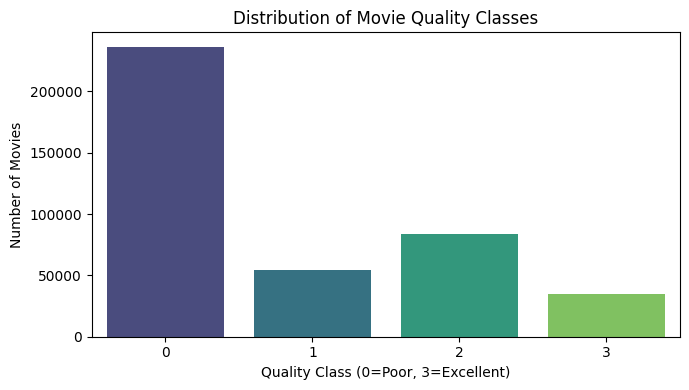

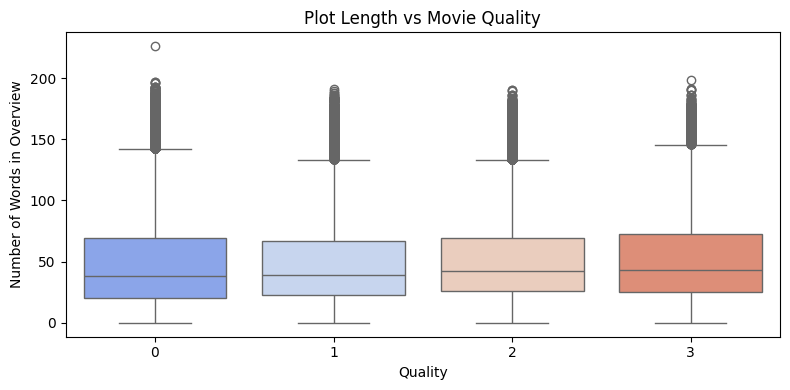

In [7]:
plt.figure(figsize=(7,4))
sns.countplot(x=df['quality'], palette='viridis')
plt.title('Distribution of Movie Quality Classes')
plt.xlabel('Quality Class (0=Poor, 3=Excellent)')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()

df['text_len'] = df['overview'].str.split().str.len()

plt.figure(figsize=(8,4))
sns.boxplot(x=df['quality'], y=df['text_len'], palette='coolwarm')
plt.title('Plot Length vs Movie Quality')
plt.xlabel('Quality')
plt.ylabel('Number of Words in Overview')
plt.tight_layout()
plt.show()


## NLP Processing

In [8]:

df['text'] = df['title'] + ' ' + df['overview']

tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts(df['text'])
vocab_size = len(tokenizer.word_index) + 1
print(f"total vocabulary size: {vocab_size}")
seq = tokenizer.texts_to_sequences(df['text'])
X_text = pad_sequences(seq, maxlen=300)
X_text.shape



total vocabulary size: 375021


(409488, 300)

## Metadata Processing

In [9]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import StandardScaler

df['log_budget'] = np.log1p(df['budget'])

scaler = StandardScaler()
X_num = scaler.fit_transform(df[['runtime','log_budget']])

df['genre_list'] = df['genres'].str.split('-')
mlb = MultiLabelBinarizer()
X_genre = mlb.fit_transform(df['genre_list'])

X_meta = pd.concat([
        pd.DataFrame(X_num, index=df.index, columns=['runtime','log_budget']),
        pd.DataFrame(X_genre, index=df.index, columns=mlb.classes_)
    ], axis=1
)

print(f"unique genres: {len(mlb.classes_)}")
print(f"total columns: {X_meta.shape[1]}")


unique genres: 20
total columns: 22


In [10]:
X_meta.head()

,runtime,log_budget,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,...,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,Unknown,War,Western
0,0.861205,5.371345,1,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0
1,0.509610,4.778285,0,0,0,0,0,0,0,0,...,1,0,1,0,0,0,1,0,0,0
2,1.185754,5.503392,1,0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,1.158708,5.503392,1,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,2.240537,5.487946,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


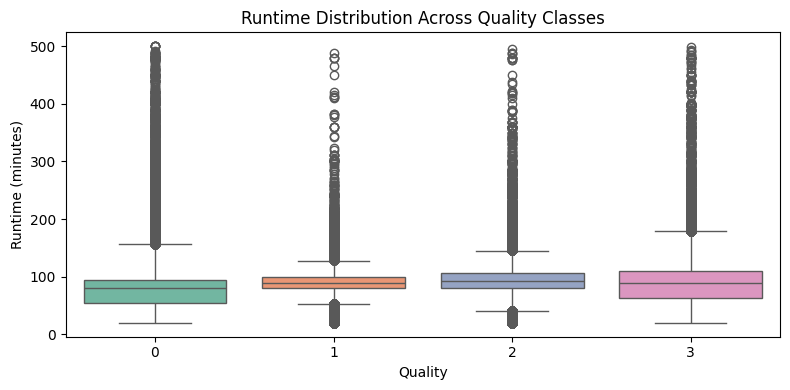

In [15]:

plt.figure(figsize=(8,4))
sns.boxplot(x=df['quality'], y=df['runtime'], palette='Set2')
plt.title('Runtime Distribution Across Quality Classes')
plt.xlabel('Quality')
plt.ylabel('Runtime (minutes)')
plt.tight_layout()
plt.show()



## Train Test Split

In [16]:

len(df)

409488

In [17]:

y = to_categorical(df['quality'], 4)

X_text_train, X_text_test, X_meta_train, X_meta_test, y_train, y_test = train_test_split(
    X_text, X_meta, y, test_size=0.2, random_state=9, stratify=y
)


## LSTM Model

In [18]:
from tensorflow.keras.layers import Dropout


In [21]:
vocab_size = 60000

text_input = Input(shape=(300,))
x = Embedding(vocab_size, 96, mask_zero=True)(text_input)
x = LSTM(96, use_cudnn=False)(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)

meta_input = Input(shape=(X_meta.shape[1],))

m = Dense(32, activation='relu')(meta_input)

combined = Concatenate()([x, m])
z = Dense(64, activation='relu')(combined)
output = Dense(4, activation='softmax')(z)

model = Model([text_input, meta_input], output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 300, 96)   │  5,760,000 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 300)       │          0 │ input_layer_3[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 96)        │     74,112 │ embedding_2[0][0… │
│                     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 96)        │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 22)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      6,208 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │        736 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 96)        │          0 │ dense_4[0][0],    │
│ (Concatenate)       │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      6,208 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 4)         │        260 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,847,524 (22.31 MB)

 Trainable params: 5,847,524 (22.31 MB)

 Non-trainable params: 0 (0.00 B)

## Training

In [22]:

model.fit(
    [X_text_train, X_meta_train],
    y_train,
    validation_split=0.1,
    epochs=7,
    batch_size=96
)


Epoch 1/7
   7/3072 ━━━━━━━━━━━━━━━━━━━━ 1:06 22ms/step - accuracy: 0.2818 - loss: 1.3787

I0000 00:00:1766151150.397778  114168 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3072/3072 ━━━━━━━━━━━━━━━━━━━━ 81s 24ms/step - accuracy: 0.5973 - loss: 1.0095 - val_accuracy: 0.6076 - val_loss: 0.9854
Epoch 2/7
3072/3072 ━━━━━━━━━━━━━━━━━━━━ 67s 22ms/step - accuracy: 0.6250 - loss: 0.9360 - val_accuracy: 0.6145 - val_loss: 0.9795
Epoch 3/7
3072/3072 ━━━━━━━━━━━━━━━━━━━━ 67s 22ms/step - accuracy: 0.6774 - loss: 0.8194 - val_accuracy: 0.6151 - val_loss: 1.0126
Epoch 4/7
3072/3072 ━━━━━━━━━━━━━━━━━━━━ 67s 22ms/step - accuracy: 0.7380 - loss: 0.6808 - val_accuracy: 0.5868 - val_loss: 1.1195
Epoch 5/7
3072/3072 ━━━━━━━━━━━━━━━━━━━━ 67s 22ms/step - accuracy: 0.7934 - loss: 0.5464 - val_accuracy: 0.5898 - val_loss: 1.3265
Epoch 6/7
3072/3072 ━━━━━━━━━━━━━━━━━━━━ 67s 22ms/step - accuracy: 0.8379 - loss: 0.4316 - val_accuracy: 0.5894 - val_loss: 1.4849
Epoch 7/7
3072/3072 ━━━━━━━━━━━━━━━━━━━━ 67s 22ms/step - accuracy: 0.8747 - loss: 0.3391 - val_accuracy: 0.5821 - val_loss: 1.8373


## Evaluation

2560/2560 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step
              precision    recall  f1-score   support

           0       0.71      0.75      0.73     47252
           1       0.36      0.27      0.31     10957
           2       0.41      0.42      0.42     16679
           3       0.32      0.29      0.31      7010

    accuracy                           0.58     81898
   macro avg       0.45      0.43      0.44     81898
weighted avg       0.57      0.58      0.57     81898



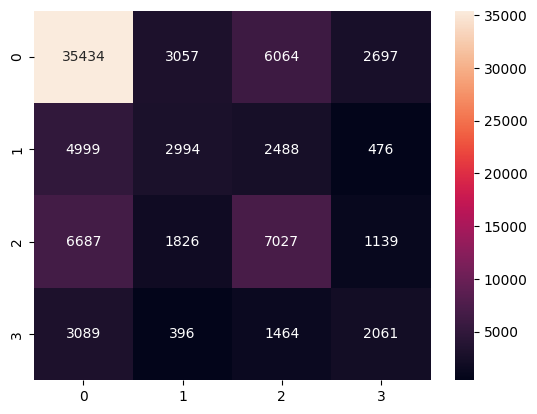

In [23]:

pred = model.predict([X_text_test, X_meta_test])
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(pred, axis=1)

print(classification_report(y_true, y_pred))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d')
plt.show()


## Plot Embeddings

In [24]:

embedding_model = Model(model.inputs, model.layers[3].output)
embeddings = embedding_model.predict([X_text, X_meta])


12797/12797 ━━━━━━━━━━━━━━━━━━━━ 45s 3ms/step


## Similarity Search

In [25]:
title_to_idx = {t.lower(): i for i, t in enumerate(df['title'])}

def similar_movies(movie_title, k=5):
    movie_title = movie_title.lower()
    if movie_title not in title_to_idx:
        return "Movie not found"
    
    idx = title_to_idx[movie_title]
    sim = cosine_similarity(embeddings[idx].reshape(1, -1),embeddings)[0]
    
    sim[idx] = -1
    top_idx = np.argsort(sim)[-k:][::-1]
    
    return df.iloc[top_idx][['title', 'vote_average', 'quality']]



## Example

In [68]:
def predict_movie_quality(title, overview, runtime, budget, genres):
    text = title + " " + overview
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=300)

    log_budget = np.log1p(budget)
    num_df = pd.DataFrame([[runtime, log_budget]], columns=['runtime', 'log_budget'])
    num_scaled = scaler.transform(num_df)

    if isinstance(genres, str):
        genres_list = [genre.strip() for genre in genres.split(',')]
    else:
        genres_list = genres
    
    genre_mlb = mlb.transform([genres_list])
    
    meta = pd.concat([
        pd.DataFrame(num_scaled, columns=['runtime', 'log_budget']), 
        pd.DataFrame(genre_mlb, columns=mlb.classes_)
    ], axis=1)

    pred = model.predict([pad, meta])
    cls = np.argmax(pred, axis=1)[0]

    labels = {
        0: "Poor",
        1: "Average", 
        2: "Good",
        3: "Excellent"
    }

    return labels[cls]

In [69]:

print("The Godfather :")
predict_movie_quality(
    title="The Godfather",
    overview="Spanning the years 1945 to 1955, a chronicle of the fictional Italian-American Corleone crime family follows the aging patriarch as he transfers control of his clandestine empire to his reluctant youngest son. As rival families vie for power, violence and betrayal threaten to destroy the delicate balance of loyalty that holds the family together. Torn between his desire for a normal life and the ruthless demands of his heritage, the son is drawn deeper into the world of organized crime, where personal ambition, honor, and revenge shape his destiny.",
    runtime=175,
    budget=60000000,
    genres="Crime, Drama"
)

The Godfather :
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


'Excellent'

In [75]:
similar_movies("The Godfather")

,title,vote_average,quality
2794,Paul,6.7,2
56196,SPFX: The Empire Strikes Back,8.6,3
85605,Youth v Gov,10.0,3
7235,A Matter of Loaf and Death,7.3,2
436553,Sun and Rain,0.0,0


In [71]:
print("Inception :")
predict_movie_quality(
    title="Inception",
    overview="A skilled thief, renowned for his ability to enter the dreams of others and steal secrets from their subconscious, is given a chance to erase his criminal past by performing an unprecedented task. Instead of extracting information, he must implant an idea deep within the mind of a powerful heir by navigating multiple layers of shared dreaming. As the team constructs elaborate dream worlds where time behaves unpredictably, the boundaries between reality and illusion begin to blur. Haunted by memories of his past and the loss of his wife, the thief struggles to maintain control as his own subconscious threatens to undermine the mission. With each descending dream layer increasing the risk, success depends on precise coordination, trust, and the ability to distinguish dreams from reality.",
    runtime=148,
    budget=160000000,
    genres="Action, Science Fiction"
)

Inception :
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


'Good'

In [30]:
print("CATS (2019) :")
predict_movie_quality(
    title="Cats",
    overview="On a single magical night, a tribe of cats known as the Jellicles gathers for their annual Jellicle Ball, where they must decide which one of them will ascend to the Heaviside Layer and be reborn into a new life. As a young and curious cat is introduced to the group, she learns about the unique personalities, pasts, and talents of the other Jellicle cats through a series of elaborate musical performances. Each cat competes for the attention of their wise leader, sharing stories of love, loss, ambition, and redemption. As tensions rise within the group, an outcast cat seeks to disrupt the ceremony for his own gain, threatening the harmony of the Jellicle Ball. Through spectacle, song, and dance, the cats confront questions of belonging, identity, and the meaning of renewal in a fantastical world where reality and imagination blur.",
    runtime=110,
    budget=950000,
    genres="Fantasy"
)


CATS (2019) :
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


('Poor',
 array([[0.67837054, 0.0129884 , 0.16118054, 0.14746043]], dtype=float32))

In [31]:
print("Captain America:Civil War")
predict_movie_quality(
    title="Captain America: Civil War",
    overview="Following a series of international incidents involving the Avengers that result in significant collateral damage, political pressure mounts to place the team under government oversight. As world leaders propose a system of accountability that would regulate the actions of super-powered individuals, the Avengers become divided over whether to accept these restrictions. Captain America believes that personal freedom and trust in individual judgment are essential, while Iron Man supports the need for control to prevent further destruction. The ideological conflict escalates into a rift that fractures long-standing alliances and forces former friends to take opposing sides. As tensions rise, a mysterious figure manipulates events from the shadows, setting the stage for a confrontation that will determine the future of the Avengers and redefine the meaning of responsibility, loyalty, and sacrifice.",
    runtime=147,
    budget=250000000,
    genres="Adventure, Action, Science Fiction"
)


Captain America:Civil War
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


('Good',
 array([[0.02258891, 0.07103205, 0.9020254 , 0.00435362]], dtype=float32))

In [32]:
print("Dhamaal (2007):")
predict_movie_quality(
    title="Dhamaal",
    overview="Four friends stumble upon the dying words of a thief who reveals the location of hidden treasure worth crores. What follows is a mad chase across the country as the friends race against time and each other to reach the treasure first. Their journey is filled with hilarious misadventures, slapstick comedy, and unexpected obstacles as they encounter quirky characters and find themselves in absurd situations. This comedy caper showcases friendship, greed, and the lengths people will go to for easy money.",
    runtime=136,
    budget=15000000,  # estimated budget in rupees, converted roughly
    genres="Comedy, Adventure"
)

Dhamaal (2007):
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


('Good',
 array([[0.00185967, 0.01045624, 0.96665376, 0.02103028]], dtype=float32))

In [33]:
print("The Shawshank Redemption (1994):")
predict_movie_quality(
    title="The Shawshank Redemption",
    overview="Framed in the 1940s for the double murder of his wife and her lover, upstanding banker Andy Dufresne is sentenced to serve two consecutive life sentences in the infamous Shawshank Prison. There, he forms a friendship with Red, experiences the brutality of prison life, adapts to the system, and eventually plans an elaborate escape.",
    runtime=142,
    budget=25000000,
    genres="Drama"
)

The Shawshank Redemption (1994):
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


('Excellent',
 array([[2.8800176e-07, 5.4506711e-07, 1.4245929e-04, 9.9985659e-01]],
       dtype=float32))

In [44]:
print("Dragonball Evolution")
predict_movie_quality(
    title="Dragonball Evolution",
    overview="A young martial artist with extraordinary abilities embarks on a journey to collect powerful mystical artifacts that can grant any wish. Guided by an experienced mentor, he must confront a dangerous adversary who seeks to dominate the world using these ancient forces. As the quest unfolds, the protagonist struggles to understand his identity and destiny, while facing poorly defined conflicts and underdeveloped characters in a narrative that diverges sharply from its source material.",
    runtime=85,
    budget=100000,
    genres="Action, Adventure, Fantasy, Science Fiction"
)


Dragonball Evolution
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


('Poor',
 array([[0.6323763 , 0.02876993, 0.33492514, 0.00392862]], dtype=float32))

In [45]:
print("The Room")
predict_movie_quality(
    title="The Room",
    overview="A successful banker lives a seemingly perfect life with his fiancée while maintaining close relationships with friends. Beneath the surface, a series of inexplicable events, awkward interactions, and emotional inconsistencies unfold as trust is broken and personal relationships deteriorate. The story attempts to explore themes of love, betrayal, and friendship but does so through disjointed scenes and illogical narrative progression.",
    runtime=99,
    budget=6000000,
    genres="Drama"
)


The Room
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


('Poor',
 array([[9.9760473e-01, 3.0255681e-04, 2.0921044e-03, 5.7087726e-07]],
       dtype=float32))

In [46]:
print("Goodfellas")
predict_movie_quality(
    title="Goodfellas",
    overview="The story follows the rise and fall of a young man who becomes deeply involved in the world of organized crime. Fascinated by the power, money, and respect associated with the mafia lifestyle, he works his way up through the ranks alongside seasoned criminals. As success brings wealth and influence, it also leads to paranoia, betrayal, and eventual consequences that expose the dark reality behind the glamorous image of gangster life.",
    runtime=146,
    budget=25000000,
    genres="Drama, Crime"
)


Goodfellas
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


('Excellent',
 array([[0.02165614, 0.05206221, 0.43960047, 0.48668116]], dtype=float32))

In [47]:
print("Se7en")
predict_movie_quality(
    title="Se7en",
    overview="Two detectives with contrasting approaches to law enforcement investigate a series of meticulously planned murders inspired by the seven deadly sins. As the investigation deepens, the case grows increasingly disturbing, forcing the detectives to confront the darker aspects of human nature. The pursuit of the elusive killer becomes a psychological battle that challenges their moral boundaries and leads to a chilling conclusion.",
    runtime=127,
    budget=33000000,
    genres="Crime, Thriller, Mystery"
)


Se7en
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


('Good',
 array([[0.00598252, 0.25474268, 0.53090686, 0.20836791]], dtype=float32))

In [54]:
print("12th Fail")
predict_movie_quality(
    title="12th Fail",
    overview="The film follows the inspiring journey of a young man from a humble background who faces repeated academic failures and societal pressure. Determined to change his fate, he embarks on a difficult path of self-discipline, perseverance, and moral integrity while preparing for one of the toughest competitive examinations in the country. His struggle highlights resilience, honesty, and the power of unwavering determination against systemic challenges.",
    runtime=147,
    budget=200000000,
    genres="Drama"
)


12th Fail
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


('Good',
 array([[0.24924508, 0.04223727, 0.6992505 , 0.00926715]], dtype=float32))

In [61]:
print("Himmatwala")
predict_movie_quality(
    title="Himmatwala",
    overview="A young man returns to his village to seek revenge against a powerful and corrupt landlord who has oppressed the local people for years. As he confronts injustice through exaggerated action sequences and implausible scenarios, the story relies heavily on outdated tropes, loud confrontations, and weak character development. The narrative struggles to maintain coherence while attempting to blend action, romance, and social drama.",
    runtime=150,
    budget=750000000,
    genres="Action, Drama"
)


Himmatwala
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


('Good',
 array([[0.00309861, 0.07926567, 0.8970175 , 0.02061826]], dtype=float32))

In [65]:
print("Dhurandhar")
predict_movie_quality(
    title="Dhurandhar",
    overview="An Indian intelligence mission unfolds over ten years as an undercover agent enters Karachi's criminal and political world to dismantle dangerous cross-border terror networks.",
    runtime=150,
    budget=3000000000,
    genres="Action, Thriller, Drama"
)


Dhurandhar
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


('Good',
 array([[3.6269057e-04, 7.6777488e-02, 9.2203063e-01, 8.2913850e-04]],
       dtype=float32))

In [73]:
print("Avatar: Fire and Ash")
predict_movie_quality(
    title="Avatar: Fire and Ash",
    overview="In the wake of the devastating war against the RDA and the loss of their eldest son, Jake Sully and Neytiri face a new threat on Pandora: the Ash People, a violent and power-hungry Na'vi tribe led by the ruthless Varang. Jake's family must fight for their survival and the future of Pandora in a conflict that pushes them to their emotional and physical limits.",
    runtime=180,
    budget=3500000000,
    genres="Science Fiction, Adventure, Action"
)


Avatar: Fire and Ash
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


'Excellent'